# Artificial Intelligence
# 464
# Project #6

## Before You Begin...
00. We're using a Jupyter Notebook environment (tutorial available here: https://jupyter-notebook-beginner-guide.readthedocs.io/en/latest/what_is_jupyter.html),
01. Read the entire notebook before beginning your work, and
02.  Check the submission deadline on Gradescope.


## General Directions for this Assignment
00. Output format should be exactly as requested,
01. Functions should do only one thing,
02. Keep functions to 20 lines or less (empty lines are fine, there's leeway, but don't blatantly ignore this),
03. Add docstring to all functions,


## Before You Submit...
00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.

## Decision Trees

For this assignment we will implement a Decision Tree using the ID3 Algorithm. The goal is classify a mushroom as either edible ('e') or poisonous ('p') using the same dataset as Project #5.


Our  Decision Tree pipeline is as follows:


1) `cross_validate` will take data (supplied as folds using 10 fold cross validation) and do the following:
* For each setting of depth limit (the hyperparameter in decision trees, including 0)
* * and for each fold of data
* * * use `create_train_test` to split current fold into train and test
* * * call `train` to build and return a decision tree, 
* * * call `classify` to use the tree to get classifications,
* * * call `evaluate` to compare classifications to the actual answers (ground truth),
* * * Print the performance for that fold
* * Summarize the performance for that depth limit over all folds using `get_stats`


2) `pretty_print_tree(tree)` will print what the tree looks like when using the **entire** data set (no train/test split) with depth limit set to None.


All the code in this pipeline has been provided, except for a working `train` function. The `train` function currently returns a hard-coded tree from our lecture. Don't do that. Use ID3 to build your tree and use the depth limit to stop. When you're train function is complete, it should work for the lecture data, and mushrooms. Although `train` is terrible right now, pay attention to how the tree is structured.

In [1]:
import random
import math
import copy
from copy import deepcopy
from typing import List, Dict, Tuple, Callable
from collections import Counter, defaultdict


<a id="note"></a>

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>
        Let's start with our example from the 08-April lecture. Target variable is Safe?, which can be yes or no. Anything *_lecture refers to the dataset we walked through in class.  
    </p>
</div>

In [2]:
data_lecture = [['round','large','blue','no'],
['square','large','green','yes'],
['square','small','red','no'],
['round','large','red','yes'],
['square','small','blue','no'],
['round','small','blue','no'],
['round','small','red','yes'],
['square','small','green','no'],
['round','large','green','yes'],
['square','large','green','yes'],
['square','large','red','no'],
['square','large','green','yes'],
['round','large','red','yes'],
['square','small','red','no'],
['round','small','green','no']]

In [3]:
print(data_lecture[0]) # a record of data

['round', 'large', 'blue', 'no']


In [4]:
len(data_lecture)

15

In [5]:
attribute_names_lecture = ['shape', 
                      'size', 
                      'color']

In [6]:
def create_folds(data: List, n: int) -> List[List[List]]:
    """
    With n-fold cross validation, we divide our data set into n subgroups called "folds" and then use those folds for training and testing. 
    For data set with 100 observations (or records), n set to 10 would have 10 observations in each fold.
    Arguments: 
        **data** List: a list (data_lecture, for instance)
        **n** int: number of folds
    Returns:
        folds, which is a list of n items, where each item is a list containing a subgroup of xs
    """
    k, m = divmod(len(data), n)
    return list(data[i * k + min(i, m):(i + 1) * k + min(i + 1, m)] for i in range(n))

In [7]:
folds_lecture = create_folds(data=data_lecture, n=10)

In [8]:
len(folds_lecture)

10

In [9]:
print(folds_lecture[0])

[['round', 'large', 'blue', 'no'], ['square', 'large', 'green', 'yes']]


In [10]:
print(folds_lecture[1])

[['square', 'small', 'red', 'no'], ['round', 'large', 'red', 'yes']]


In [11]:
def create_train_test(folds: List[List[List]], index: int) -> Tuple[List[List], List[List]]:
    """
    This function takes the n folds and returns the train and test sets. One of the n folds is used to test, the others are used for training.
    Argumnents:
        **folds** List[List[List]]: see `create_folds`
        **index** int: fold index that is used for testing
    Returns:
        folds, which is a list of n items, where each item is a list containing a subgroup of xs
    """
    training = []
    test = []
    for i, fold in enumerate(folds):
        if i == index:
            test = fold
        else:
            training = training + fold
    return training, test

In [12]:
train_lecture, test_lecture = create_train_test(folds_lecture, 0) # test data is folds_lecture index 0

In [13]:
print(train_lecture)

[['square', 'small', 'red', 'no'], ['round', 'large', 'red', 'yes'], ['square', 'small', 'blue', 'no'], ['round', 'small', 'blue', 'no'], ['round', 'small', 'red', 'yes'], ['square', 'small', 'green', 'no'], ['round', 'large', 'green', 'yes'], ['square', 'large', 'green', 'yes'], ['square', 'large', 'red', 'no'], ['square', 'large', 'green', 'yes'], ['round', 'large', 'red', 'yes'], ['square', 'small', 'red', 'no'], ['round', 'small', 'green', 'no']]


In [14]:
print(test_lecture)

[['round', 'large', 'blue', 'no'], ['square', 'large', 'green', 'yes']]


In [15]:
train_lecture, test_lecture = create_train_test(folds_lecture, 1) # test data is folds_lecture index 1

In [16]:
print(train_lecture)

[['round', 'large', 'blue', 'no'], ['square', 'large', 'green', 'yes'], ['square', 'small', 'blue', 'no'], ['round', 'small', 'blue', 'no'], ['round', 'small', 'red', 'yes'], ['square', 'small', 'green', 'no'], ['round', 'large', 'green', 'yes'], ['square', 'large', 'green', 'yes'], ['square', 'large', 'red', 'no'], ['square', 'large', 'green', 'yes'], ['round', 'large', 'red', 'yes'], ['square', 'small', 'red', 'no'], ['round', 'small', 'green', 'no']]


In [17]:
print(test_lecture)

[['square', 'small', 'red', 'no'], ['round', 'large', 'red', 'yes']]


<a id="note"></a>

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <p>
        Let's load the mushroom data.
    </p>
</div>

In [18]:
def parse_data(file_name: str) -> List[List]:
    """
    Opens a file, splits on comma, and shuffles data before returning as a List of list. 
    Arguments:
        **file_name** Str: filename for data
    Returns:
        Data as a list of a list.
    """
    data = []
    file = open(file_name, "r")
    for line in file:
        datum = [value for value in line.rstrip().split(",")]
        data.append(datum)
    random.shuffle(data)
    return data

In [19]:
data_mushroom = parse_data("agaricus-lepiota.data")

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Important</strong>
    <p>
        We're going to move the target column (mushroom edible or poisonous) to the last column to match the lecture's format, where Safe? was at the end.
    </p>
</div>

In [20]:
data_mushroom = [record[1:]+[record[0]] for record in data_mushroom]

In [21]:
len(data_mushroom)

8124

In [22]:
print(data_mushroom[0])

['f', 'f', 'g', 'f', 'n', 'f', 'w', 'b', 'p', 't', 'e', 's', 's', 'w', 'w', 'p', 'w', 'o', 'e', 'n', 'a', 'g', 'e']


In [23]:
attribute_names_mushroom = ['cap-shape',
                   'cap-surface',
                   'cap-color',
                   'bruises?',
                   'odor',
                   'gill-attachment',
                   'gill-spacing',
                   'gill-size',
                   'gill-color',
                   'stalk-shape',
                   'stalk-root',
                   'stalk-surface-above-ring',
                   'stalk-surface-below-ring',
                   'stalk-color-above-ring',
                   'stalk-color-below-ring',
                   'veil-type',
                   'veil-color',
                   'ring-number',
                   'ring-type',
                   'spore-print-color',
                   'population',
                   'habitat']

In [24]:
def get_answers(data):
    """
    This function extracts a list of the target values from data. The function assumes the target variable is the last column of the data.
    Arguments:
        **data** List[List]: The data provided in a list of list format identical to the structure of `data_lecture` or `data_mushroom`
    Returns:
        A list of the values of the target variable.
    """
    return [record[-1] for record in data]

In [25]:
assert get_answers([]) == []
assert get_answers(data_lecture) == ['no', 'yes', 'no', 'yes', 'no', 'no', 'yes', 'no', 'yes', 'yes', 'no', 'yes', 'yes', 'no', 'no']

In [26]:
def get_mode(answers):
    """
    This function finds the mode of a list of items. 
    Arguments:
        **answers** List: A list of items
    Returns:
        The item that appears the most often in the list. 
    """
    count_dict = {}
    for answer in answers:
        if answer in count_dict:
            count_dict[answer] = count_dict[answer] + 1
        else:
            count_dict[answer] = 1
    mode_count = max(count_dict.values())
    mode = [k for k, v in count_dict.items() if v == mode_count]
    return mode[0]

In [27]:
assert get_mode(['no', 'no', 'no', 'yes']) == 'no'
assert get_mode(['no', 'no', 'yes', 'yes']) == 'no'
assert get_mode(['no', 'yes', 'yes', 'yes']) == 'yes'

In [28]:
import math
from collections import Counter, defaultdict

def entropy(labels):
    """Compute Shannon entropy of the given class label list."""
    total = len(labels)
    freqs = Counter(labels)
    # Sum over −p * log2(p) for each class
    return -sum(
        (count/total) * math.log2(count/total)
        for count in freqs.values()
    )

def majority_class(labels):
    """Return the most common label from the list."""
    return Counter(labels).most_common(1)[0][0]

def information_gain(data, attr_index):
    """Calculate information gain of splitting data on the given attribute index."""
    # Entropy before the split
    base = entropy([row[-1] for row in data])

    # Partition data by each value of attribute[attr_index]
    parts = defaultdict(list)
    for row in data:
        parts[row[attr_index]].append(row)

    # Compute the weighted entropy after the split
    weighted = sum(
        (len(sub)/len(data)) * entropy([r[-1] for r in sub])
        for sub in parts.values()
    )

    # Gain = entropy(before) − weighted entropy(after)
    return base - weighted

def id3(data, names, idxs, depth):
    """
    Recursively build an ID3 tree.
    Keys are tuples: (attribute_name, original_index, attribute_value).
    """
    labels = [row[-1] for row in data]

    # 1) If all labels are the same, return that label (pure node)
    if len(set(labels)) == 1:
        return labels[0]

    # 2) If no more attributes or reached depth limit, return majority class
    if not names or (depth is not None and depth == 0):
        return majority_class(labels)

    # 3) Select the best attribute by highest information gain
    gains = [(information_gain(data, i), i) for i in range(len(names))]
    _, best_i = max(gains, key=lambda x: x[0])
    best_name, best_idx = names[best_i], idxs[best_i]

    tree = {}
    # 4) Partition data on the chosen attribute
    parts = defaultdict(list)
    for row in data:
        parts[row[best_i]].append(row)

    # 5) For each partition, recurse to build subtrees
    for val, subset in parts.items():
        # Remove the used attribute column from data and names
        trimmed = [r[:best_i] + r[best_i+1:] for r in subset]
        sub_names = names[:best_i] + names[best_i+1:]
        sub_idxs  = idxs[:best_i]  + idxs[best_i+1:]

        # Recurse, decreasing depth if a limit was set
        subtree = id3(
            trimmed, sub_names, sub_idxs,
            None if depth is None else depth-1
        )
        tree[(best_name, best_idx, val)] = subtree

    return tree

def train(training_data, attribute_names, depth_limit=None):
    """Train an ID3 decision tree on the given data and attribute names."""
    idxs = list(range(len(attribute_names)))  # track original column positions
    return id3(training_data, attribute_names.copy(), idxs, depth_limit)



In [29]:
dt_lecture = train(training_data=train_lecture, attribute_names=attribute_names_lecture, depth_limit=0)

In [30]:
def get_prediction(record, dt):
    """
    This recursive function uses a decision tree represented as a nested dictionary get a prediction from a record, which is a row of the data. 
    Arguments:
        **record** List[]: A row of data to be predicted
        **dt** the decision tree used to make the prediction
    Returns:
        A prediction ('yes' or 'no' for instance, from our Self Check example.) 
    """
    if not isinstance(dt, dict):
        return dt
    else:
        for key, value in dt.items():
            if record[key[1]]==key[2]:
                return get_prediction(record, value)

In [31]:
print(get_prediction(['round','large','blue','no'], dt=dt_lecture))
print(get_prediction(['square','large','green','yes'], dt=dt_lecture))
print(get_prediction(['square','small','red','no'], dt=dt_lecture))

no
no
no


In [32]:
def classify(dt, observations):
    """
    This function takes a decision tree, observations, and a labeled flag to return a list of classifications. 
    Arguments:
        **dt** Dict: The decision tree as a nested dictionary
        **observation** List[List]: a list of items, where each item is a row of the data
        **labeled** Bool: true for labeled data
    Returns:
        **y_hat** List: A list of classifications.
    """
    y_hat = []
    for record in observations:
        y_hat.append(get_prediction(record, dt))   
    return y_hat

In [33]:
print(classify(dt=dt_lecture, observations=test_lecture))

['no', 'no']


In [34]:
def evaluate(y_hat, observations):
    """
    This function evaluates the performance of a classifier. 
    It takes a data set (training set or test set) and the classification result (see [classify](#classify) above and calculates the classification error rate:
        $$error\_rate=\frac{errors}{n}$$ 
    Arguments:
        **y_hat** List: A list of predictions
        **observations** List[List]: Data to be predicted (typically training or test set)
    Returns:
        **error_rate** float: The error rate.
    """
    errors = 0
    ground_truth = get_answers(observations)
    for index in range(len(y_hat)):
        if y_hat[index] != ground_truth[index]:
            errors = errors + 1
    return errors / (len(y_hat))

<>:2: SyntaxWarning: invalid escape sequence '\_'
<>:2: SyntaxWarning: invalid escape sequence '\_'
/var/folders/s3/wlqzy22n6hq4f0rzy825qp4h0000gn/T/ipykernel_35151/3381848552.py:2: SyntaxWarning: invalid escape sequence '\_'
  """


In [35]:
print(evaluate(classify(dt=dt_lecture, observations=data_lecture), observations=data_lecture))

0.4666666666666667


<a id="get_stats"></a>
## get_stats



In [36]:
def get_stats(observations: List[float]) -> Tuple[float,float]:
    """
    This function computes the mean and the standard deviation for a given list of observations. 
    Arguments:
        **observations** List[float]: A list of observations
    Returns:
        (mean, standard deviation) Tuple[float,float]: tuple consisting of mean and the standard deviation
    """
    mean = sum(observations) / len(observations)
    variance = sum([(elem - mean)**2 for elem in observations]) / len(observations)
    std_dev = math.sqrt(variance)
    return mean, std_dev

In [37]:
assert get_stats([2, 4, 4, 4, 5, 5, 7, 9]) == (5.0, 2.0)
assert get_stats([1, 1, 1]) == (1.0, 0.0)
assert get_stats([0]) == (0.0, 0.0)

In [38]:
def cross_validate(folds, attribute_names, hyperparameters):
    """
    This function takes folds of data to `train`, `classify`, and `evaluate`.
    Arguments:
        **folds** List[List[List]]: The original dataset partitioned into folds (see `create_folds` above)
        **attribute_names** int: the feature names
        **hyperparameters** List: A list of hyperparameters to explore (depth limits for a decision tree, for instance)
    Returns:
        Nothing is returned, but for each hyperparameter setting, the function prints out the fold number and the error rate for that fold. 
        The mean and variance is printed across folds for each hyperparameter setting. 
        The error rates are reported in terms of percents.
    """
    for hyperparameter in hyperparameters:
        train_error, test_error  = [], []
        error_list_train, error_list_test = [], []
        for fold_index in range(len(folds)):
            training_data, test_data = create_train_test(folds, fold_index)
            tree = train(training_data=training_data, attribute_names=attribute_names, depth_limit=hyperparameter)
            y_hat_train = classify(tree, training_data)
            y_hat_test = classify(tree, test_data)
            error_rate_train = evaluate(y_hat_train, training_data)
            error_rate_test = evaluate(y_hat_test, test_data)
            error_list_train.append(error_rate_train)
            error_list_test.append(error_rate_test)
            print(f"Fold: {fold_index}\tTrain Error: {error_rate_train*100:.2f}%\tTest Error: {error_rate_test*100:.2f}%")
        print(f"***")
        print(f"Depth limit: {hyperparameter}")
        print(f"\nMean(Std. Dev.) over all folds:\n-------------------------------")
        print(f"Train Error: {get_stats(error_list_train)[0]*100:.2f}%({get_stats(error_list_train)[1]*100:.2f}%) Test Error: {get_stats(error_list_test)[0]*100:.2f}%({get_stats(error_list_test)[1]*100:.2f}%)")
        print("\n")

In [39]:
cross_validate(folds=folds_lecture, attribute_names=attribute_names_lecture, hyperparameters=[0, 1, 2, 3, 4, 5, None])

Fold: 0	Train Error: 46.15%	Test Error: 50.00%
Fold: 1	Train Error: 46.15%	Test Error: 50.00%
Fold: 2	Train Error: 46.15%	Test Error: 100.00%
Fold: 3	Train Error: 46.15%	Test Error: 50.00%
Fold: 4	Train Error: 38.46%	Test Error: 100.00%
Fold: 5	Train Error: 50.00%	Test Error: 0.00%
Fold: 6	Train Error: 42.86%	Test Error: 100.00%
Fold: 7	Train Error: 42.86%	Test Error: 100.00%
Fold: 8	Train Error: 50.00%	Test Error: 0.00%
Fold: 9	Train Error: 50.00%	Test Error: 0.00%
***
Depth limit: 0

Mean(Std. Dev.) over all folds:
-------------------------------
Train Error: 45.88%(3.53%) Test Error: 55.00%(41.53%)


Fold: 0	Train Error: 15.38%	Test Error: 50.00%
Fold: 1	Train Error: 30.77%	Test Error: 50.00%
Fold: 2	Train Error: 23.08%	Test Error: 0.00%
Fold: 3	Train Error: 15.38%	Test Error: 50.00%
Fold: 4	Train Error: 23.08%	Test Error: 0.00%
Fold: 5	Train Error: 14.29%	Test Error: 100.00%
Fold: 6	Train Error: 21.43%	Test Error: 0.00%
Fold: 7	Train Error: 21.43%	Test Error: 0.00%
Fold: 8	Train Er

In [40]:
def pretty_print_tree(dt, tab_space):
    """
    This function provides a text-based representation of a decision tree that is represented as a nested dictionary. 
    Arguments:
        **dt** Dict: The decision tree as a nested dictionary
        **tab_space** Int: How much to tab successive depth levels of the resulting tree
    """
    for key, value in dt.items():
        if isinstance(value, dict):
            print("  " * tab_space + str(key[0]).upper() + " - " + str(key[2]) + ": ")
            print("\n")
            pretty_print_tree(value, tab_space+3)
        else:
            print("  " * tab_space + str(key[0]).upper() + " - " + str(key[2]) + " =====> " + str(value))
            print("\n")

In [41]:
dt_lecture = train(training_data=data_lecture, attribute_names=attribute_names_lecture, depth_limit=None)
pretty_print_tree(dt_lecture, tab_space=0)

SIZE - large: 


      COLOR - blue =====> no


      COLOR - green =====> yes


      COLOR - red: 


            SHAPE - round =====> yes


            SHAPE - square =====> no


SIZE - small: 


      SHAPE - square =====> no


      SHAPE - round: 


            COLOR - blue =====> no


            COLOR - red =====> yes


            COLOR - green =====> no




<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <p>
        Let's work on the mushroom data. 
    </p>
</div>

## Classify the Mushrooom data

In [42]:
folds_mushroom = create_folds(data=data_mushroom, n=10)

In [43]:
cross_validate(folds=folds_mushroom, attribute_names=attribute_names_mushroom, hyperparameters=[0, 1, 2, 3, 4, 5, None])

Fold: 0	Train Error: 48.37%	Test Error: 46.74%
Fold: 1	Train Error: 48.49%	Test Error: 45.63%
Fold: 2	Train Error: 48.00%	Test Error: 50.06%
Fold: 3	Train Error: 48.16%	Test Error: 48.59%
Fold: 4	Train Error: 47.96%	Test Error: 50.37%
Fold: 5	Train Error: 48.10%	Test Error: 49.14%
Fold: 6	Train Error: 48.50%	Test Error: 45.57%
Fold: 7	Train Error: 48.13%	Test Error: 48.89%
Fold: 8	Train Error: 48.22%	Test Error: 48.03%
Fold: 9	Train Error: 48.11%	Test Error: 49.01%
***
Depth limit: 0

Mean(Std. Dev.) over all folds:
-------------------------------
Train Error: 48.20%(0.18%) Test Error: 48.20%(1.61%)


Fold: 0	Train Error: 1.52%	Test Error: 1.11%
Fold: 1	Train Error: 1.42%	Test Error: 1.97%
Fold: 2	Train Error: 1.41%	Test Error: 2.09%
Fold: 3	Train Error: 1.45%	Test Error: 1.72%
Fold: 4	Train Error: 1.53%	Test Error: 0.99%
Fold: 5	Train Error: 1.45%	Test Error: 1.72%
Fold: 6	Train Error: 1.49%	Test Error: 1.35%
Fold: 7	Train Error: 1.49%	Test Error: 1.35%
Fold: 8	Train Error: 1.49%	Test

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <p>
        Let's work on the mushroom data. 
    </p>
</div>

## Print the Mushroom Tree

In [44]:
dt_mushroom = train(training_data=data_mushroom, attribute_names=attribute_names_mushroom, depth_limit=None)
pretty_print_tree(dt_mushroom, tab_space=0)

ODOR - n: 


      SPORE-PRINT-COLOR - n =====> e


      SPORE-PRINT-COLOR - w: 


            HABITAT - w =====> e


            HABITAT - l: 


                  CAP-COLOR - y =====> p


                  CAP-COLOR - c =====> e


                  CAP-COLOR - n =====> e


                  CAP-COLOR - w =====> p


            HABITAT - p =====> e


            HABITAT - g =====> e


            HABITAT - d: 


                  GILL-SIZE - n =====> p


                  GILL-SIZE - b =====> e


      SPORE-PRINT-COLOR - k =====> e


      SPORE-PRINT-COLOR - r =====> p


      SPORE-PRINT-COLOR - h =====> e


      SPORE-PRINT-COLOR - y =====> e


      SPORE-PRINT-COLOR - b =====> e


      SPORE-PRINT-COLOR - o =====> e


ODOR - f =====> p


ODOR - y =====> p


ODOR - l =====> e


ODOR - p =====> p


ODOR - s =====> p


ODOR - a =====> e


ODOR - c =====> p


ODOR - m =====> p




## Use a library for the following:

Use an AI/ML library to build and display the best tree using your chosen library.  

Depth  →  Mean CV Accuracy
    0  →  51.797%
    1  →  88.676%
    2  →  92.713%
    3  →  96.159%
    4  →  98.720%
    5  →  99.951%

🏆 Best depth = 5, CV accuracy = 99.951%

Classification Report:
               precision    recall  f1-score   support

           e       1.00      1.00      1.00      4208
           p       1.00      1.00      1.00      3916

    accuracy                           1.00      8124
   macro avg       1.00      1.00      1.00      8124
weighted avg       1.00      1.00      1.00      8124

Confusion Matrix:
 [[4208    0]
 [   4 3912]]

Decision Tree (depth ≤ 5):
 |--- odor_n <= 0.50
|   |--- bruises?_f <= 0.50
|   |   |--- stalk-root_c <= 0.50
|   |   |   |--- stalk-root_r <= 0.50
|   |   |   |   |--- habitat_d <= 0.50
|   |   |   |   |   |--- class: p
|   |   |   |   |--- habitat_d >  0.50
|   |   |   |   |   |--- class: e
|   |   |   |--- stalk-root_r >  0.50
|   |   |   |   |--- class: e
|   |   |--- stalk-root_c >  0.50
|   |   |   |--- class: e
|  

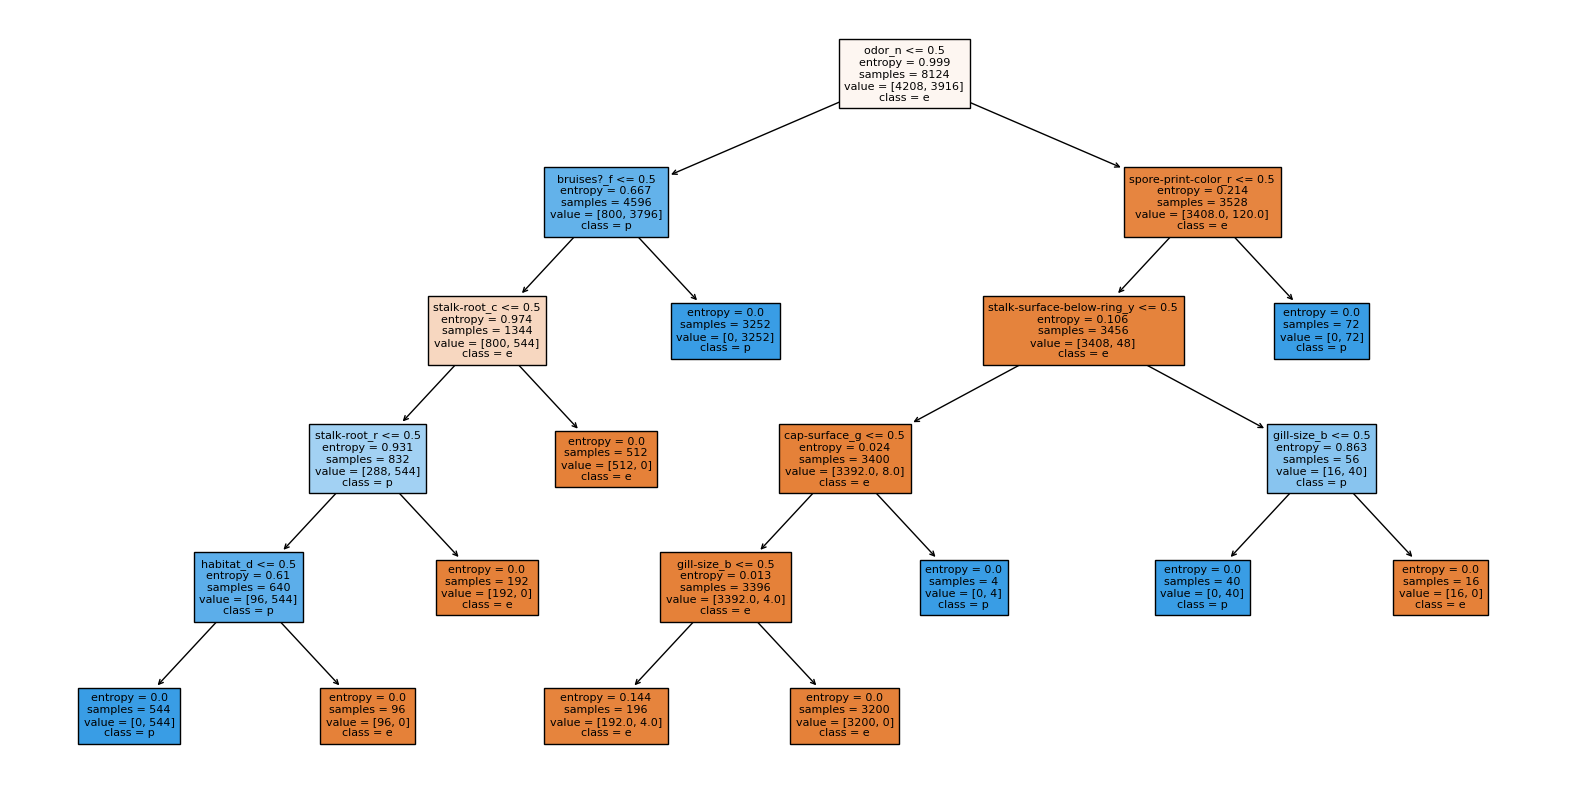

Top 10 Features:
odor_n: 0.531
bruises?_f: 0.217
stalk-root_c: 0.066
spore-print-color_r: 0.048
habitat_d: 0.048
stalk-root_r: 0.047
stalk-surface-below-ring_y: 0.029
gill-size_b: 0.008
cap-surface_g: 0.005
cap-shape_s: 0.000


In [45]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
import numpy as np
import matplotlib.pyplot as plt

# 1) Prepare feature matrix and labels
X = np.array([record[:-1] for record in data_mushroom])
y = np.array([record[-1]      for record in data_mushroom])

# 2) One-hot encode into a dense array
enc = OneHotEncoder(handle_unknown="ignore")
X_enc = enc.fit_transform(X).toarray()

# 3) 10-fold CV across integer depths [0 (baseline), 1–5]
depths = [0, 1, 2, 3, 4, 5]
cv_results = {}
print("Depth  →  Mean CV Accuracy")
for d in depths:
    if d == 0:
        clf_cv = DummyClassifier(strategy="most_frequent")
    else:
        clf_cv = DecisionTreeClassifier(
            criterion="entropy",
            max_depth=d,
            random_state=42
        )
    scores = cross_val_score(clf_cv, X_enc, y, cv=10, scoring="accuracy")
    cv_results[d] = scores.mean()
    print(f"{d:>5d}  →  {cv_results[d]:.3%}")

# 4) Select best_depth (will always be an int ≥0)
best_depth = max(cv_results, key=cv_results.get)
print(f"\n🏆 Best depth = {best_depth}, CV accuracy = {cv_results[best_depth]:.3%}")

# 5) Retrain final model on the full dataset
if best_depth == 0:
    final_clf = DummyClassifier(strategy="most_frequent")
else:
    final_clf = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=best_depth,
        random_state=42
    )
final_clf.fit(X_enc, y)

# 6) Evaluate on full data
y_pred = final_clf.predict(X_enc)
print("\nClassification Report:\n", classification_report(y, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

# 7) If we have a real tree (best_depth ≥1), dump and plot up to that depth
if best_depth > 0:
    # 7a) Textual dump
    tree_text = export_text(
        final_clf,
        feature_names=list(enc.get_feature_names_out(attribute_names_mushroom)),
        max_depth=best_depth
    )
    print(f"\nDecision Tree (depth ≤ {best_depth}):\n", tree_text)

    # 7b) Graphical plot
    plt.figure(figsize=(20, 10))
    plot_tree(
        final_clf,
        filled=True,
        feature_names=enc.get_feature_names_out(attribute_names_mushroom),
        class_names=final_clf.classes_,
        max_depth=best_depth,
        fontsize=8
    )
    plt.show()

    # 8) Top 10 feature importances
    importances = final_clf.feature_importances_
    feat_names  = enc.get_feature_names_out(attribute_names_mushroom)
    top_idx     = np.argsort(importances)[::-1][:10]
    print("Top 10 Features:")
    for i in top_idx:
        print(f"{feat_names[i]}: {importances[i]:.3f}")
else:
    print("\nDepth=0 → baseline model; no tree to display.")


## Before You Submit...

00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.